# Telco Churn - Phase 5: Explainability (SHAP and LIME)

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

sys.path.append(str(Path("..").resolve()))

from src.explainability import (
    compute_shap_values,
    explain_with_lime,
    get_top_shap_features,
    plot_shap_bar,
    plot_shap_dependence,
    plot_shap_summary,
)
from src.models import load_processed_data

/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Load Best Model and Processed Data

In [2]:
x_train, x_test, y_train, y_test = load_processed_data("../data/processed")
best_model = joblib.load("../models/best_model.joblib")
best_threshold = float(joblib.load("../models/best_threshold.joblib"))

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("Best threshold:", round(best_threshold, 4))
print("Model type:", type(best_model).__name__)

x_train: (5634, 40)
x_test: (1409, 40)
Best threshold: 0.5406
Model type: LogisticRegression


## 2) SHAP Global Explanations

Top SHAP features:
['tenure', 'InternetService_Fiber optic', 'contract_risk_score', 'is_new_customer', 'Contract_Two year', 'PaperlessBilling', 'TotalCharges', 'charge_per_service', 'avg_monthly_charge', 'MonthlyCharges', 'OnlineSecurity_Yes', 'StreamingMovies_Yes', 'StreamingTV_Yes', 'Contract_One year', 'TechSupport_Yes']


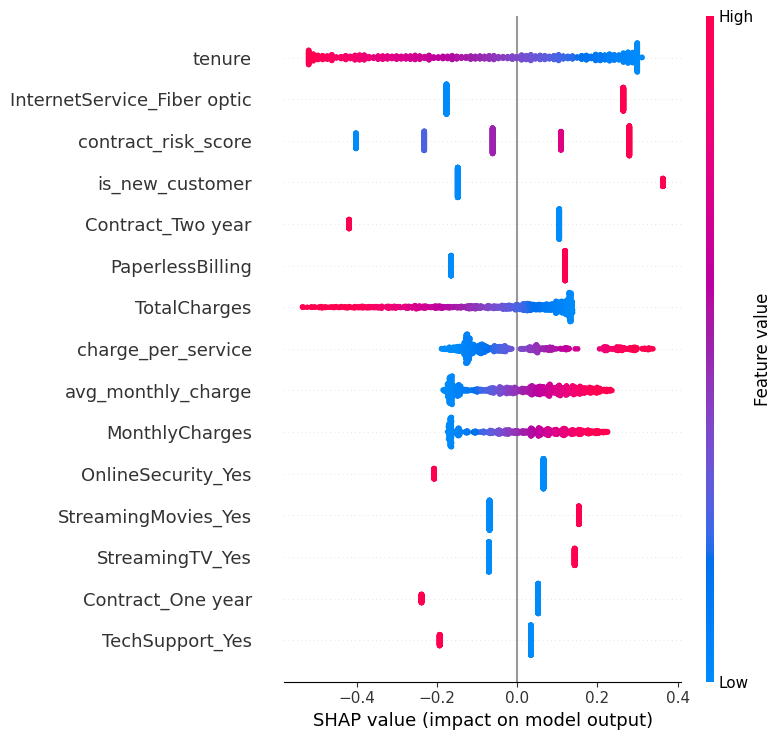

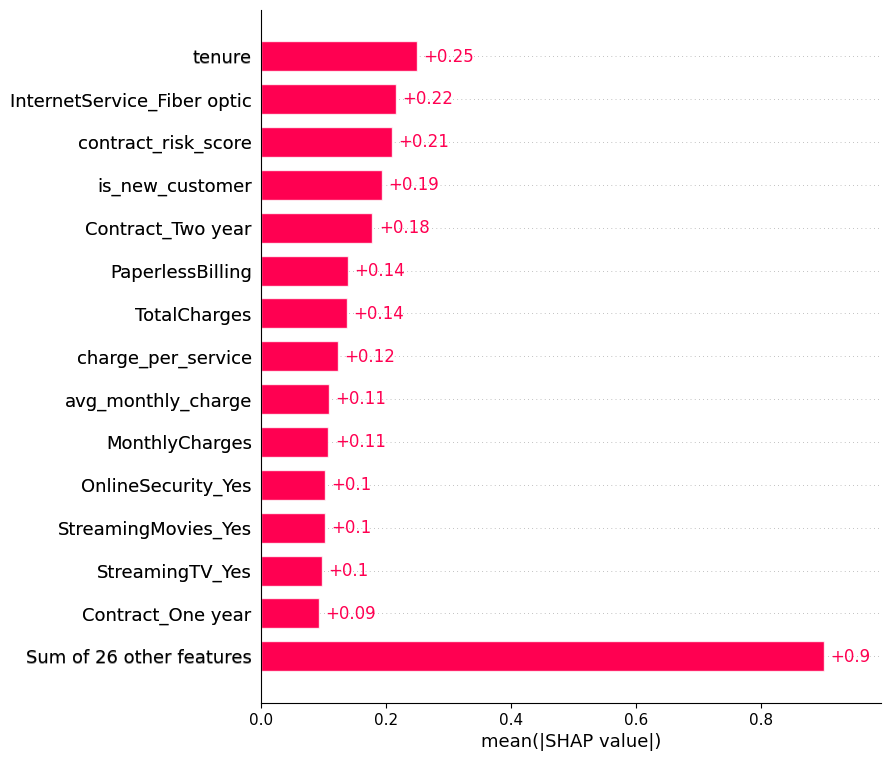

In [3]:
shap_values, x_shap = compute_shap_values(best_model, x_test, max_samples=1000)
feature_names = list(x_shap.columns)

top_features = get_top_shap_features(shap_values, feature_names, top_n=15)
print("Top SHAP features:")
print(top_features)

plot_shap_summary(shap_values, x_shap, max_display=15)
plot_shap_bar(shap_values, max_display=15)

Dependence features: ['tenure', 'MonthlyCharges', 'contract_risk_score']


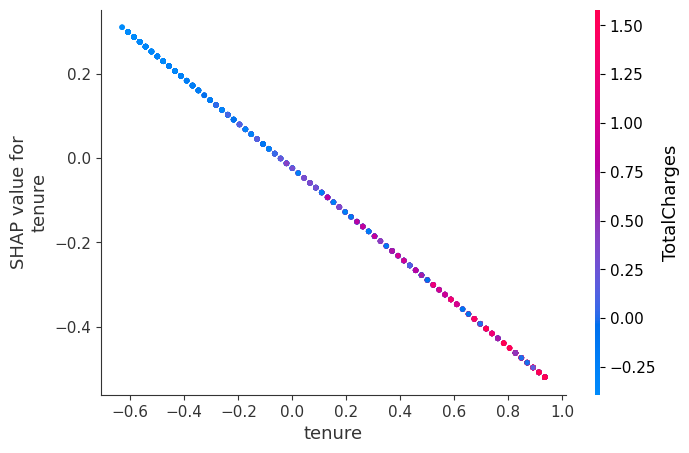

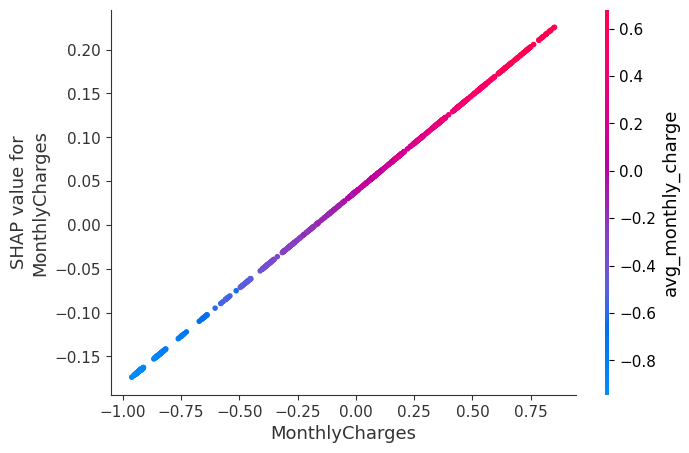

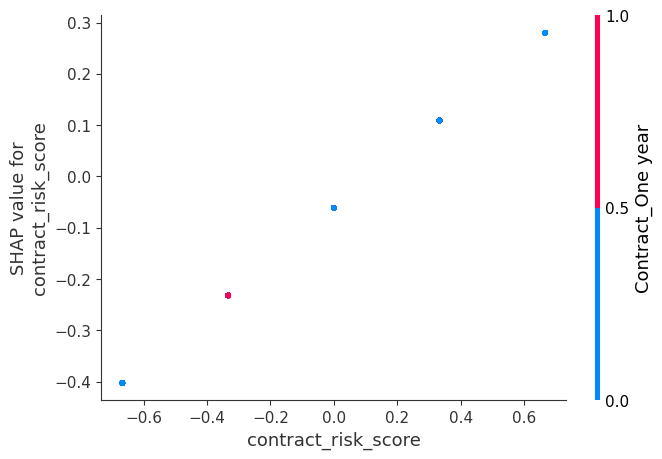

In [4]:
default_dependence_candidates = ["tenure", "MonthlyCharges", "contract_risk_score"]
dependence_features = [f for f in default_dependence_candidates if f in x_shap.columns]

if len(dependence_features) < 3:
    extra = [f for f in top_features if f not in dependence_features]
    dependence_features.extend(extra[: 3 - len(dependence_features)])

print("Dependence features:", dependence_features)
for feat in dependence_features[:3]:
    plot_shap_dependence(shap_values, feat, x_shap)

## 3) LIME Local Explanations (3 Customers)

In [5]:
y_proba = best_model.predict_proba(x_test)[:, 1]
pred_df = pd.DataFrame(
    {
        "index": x_test.index,
        "y_true": y_test.values,
        "y_proba": y_proba,
    }
)

high_idx = int(pred_df.sort_values("y_proba", ascending=False).iloc[0]["index"])
low_idx = int(pred_df.sort_values("y_proba", ascending=True).iloc[0]["index"])
borderline_idx = int((pred_df["y_proba"] - 0.5).abs().sort_values().index[0])

instance_ids = {
    "high_risk_churn": high_idx,
    "low_risk_stay": low_idx,
    "borderline": borderline_idx,
}
instance_ids

{'high_risk_churn': 889, 'low_risk_stay': 162, 'borderline': 496}

/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


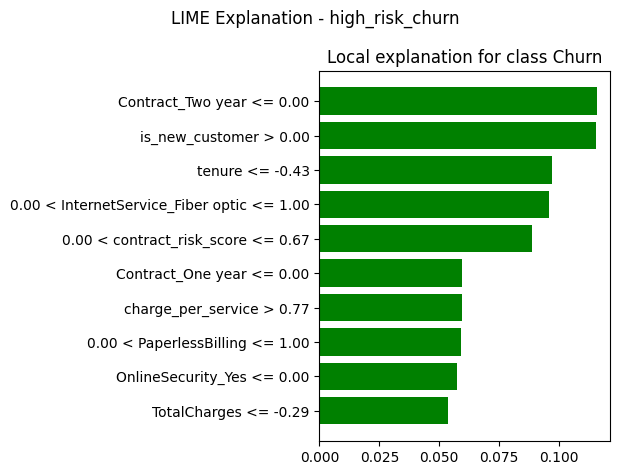

/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


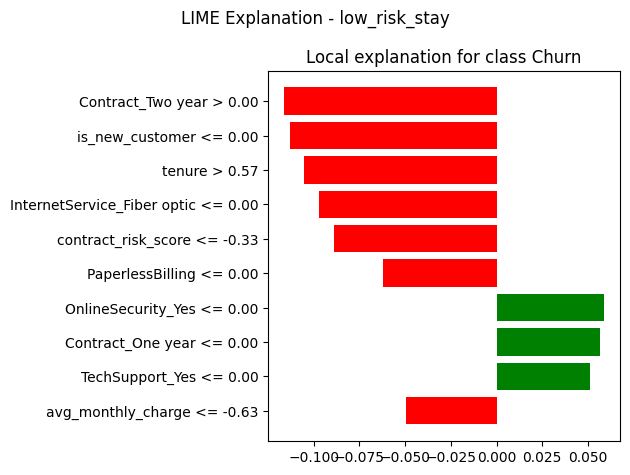

/Users/backup/Desktop/Telco customer Churn/.venv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


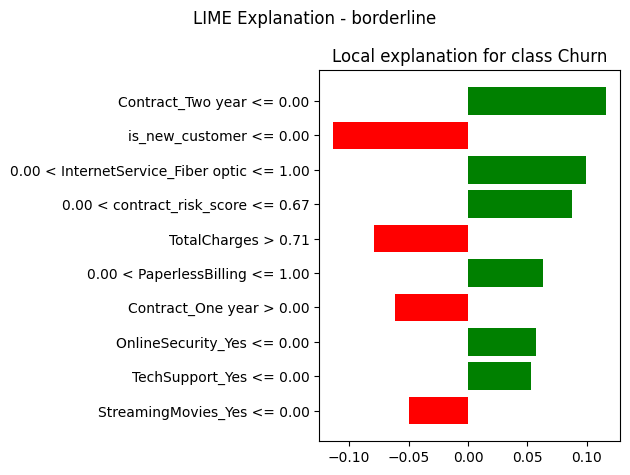

high_risk_churn index= 889 pred_proba= 0.9389
Top factors: [('Contract_Two year <= 0.00', 0.11562075039285984), ('is_new_customer > 0.00', 0.115246180261808), ('tenure <= -0.43', 0.0968485394411481), ('0.00 < InternetService_Fiber optic <= 1.00', 0.09594907471469255), ('0.00 < contract_risk_score <= 0.67', 0.08864707049612047)]

low_risk_stay index= 162 pred_proba= 0.034
Top factors: [('Contract_Two year > 0.00', -0.1160708980028987), ('is_new_customer <= 0.00', -0.11301517336235659), ('tenure > 0.57', -0.10532019413112083), ('InternetService_Fiber optic <= 0.00', -0.0970872142988188), ('contract_risk_score <= -0.33', -0.0890132114933933)]

borderline index= 496 pred_proba= 0.5005
Top factors: [('Contract_Two year <= 0.00', 0.11633691972384572), ('is_new_customer <= 0.00', -0.1133989769744469), ('0.00 < InternetService_Fiber optic <= 1.00', 0.09952599180878192), ('0.00 < contract_risk_score <= 0.67', 0.08765857031394121), ('TotalCharges > 0.71', -0.07893857764202872)]



In [6]:
lime_results = {}
for label, idx in instance_ids.items():
    instance = x_test.loc[idx]
    lime_exp = explain_with_lime(
        model=best_model,
        x_train=x_train,
        instance=instance,
        feature_names=list(x_train.columns),
        num_features=10,
    )
    lime_results[label] = {
        "index": idx,
        "pred_proba": float(best_model.predict_proba(instance.to_frame().T)[:, 1][0]),
        "explanation": lime_exp.as_list(),
    }
    fig = lime_exp.as_pyplot_figure()
    fig.suptitle(f"LIME Explanation - {label}")
    plt.tight_layout()
    plt.show()

for label, data in lime_results.items():
    print(label, "index=", data["index"], "pred_proba=", round(data["pred_proba"], 4))
    print("Top factors:", data["explanation"][:5])
    print()

## 4) SHAP vs LIME Comparison (Same 3 Customers)

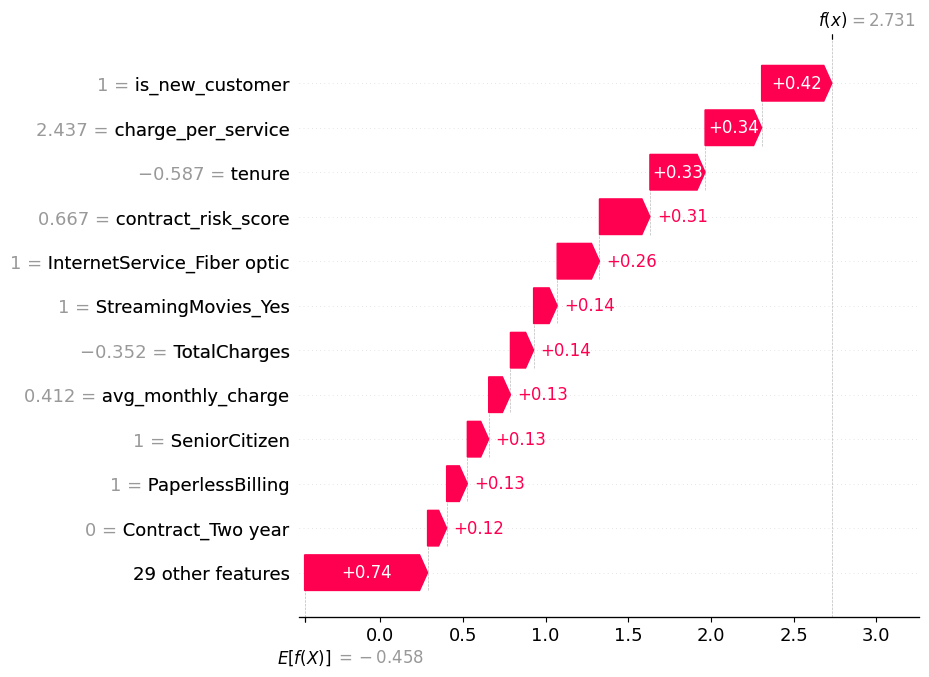

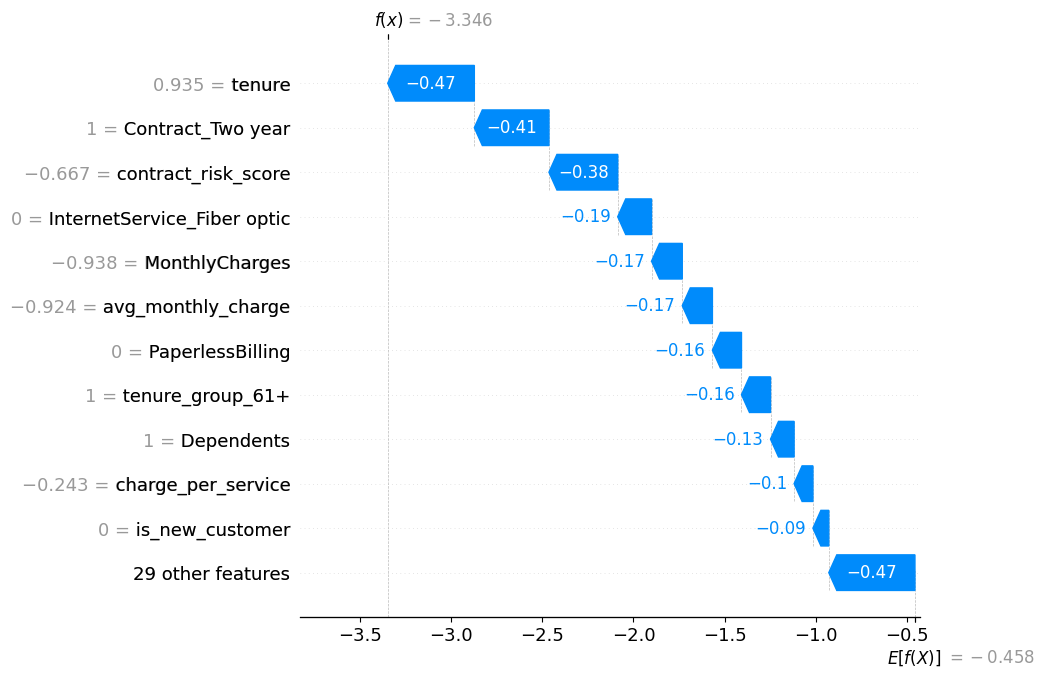

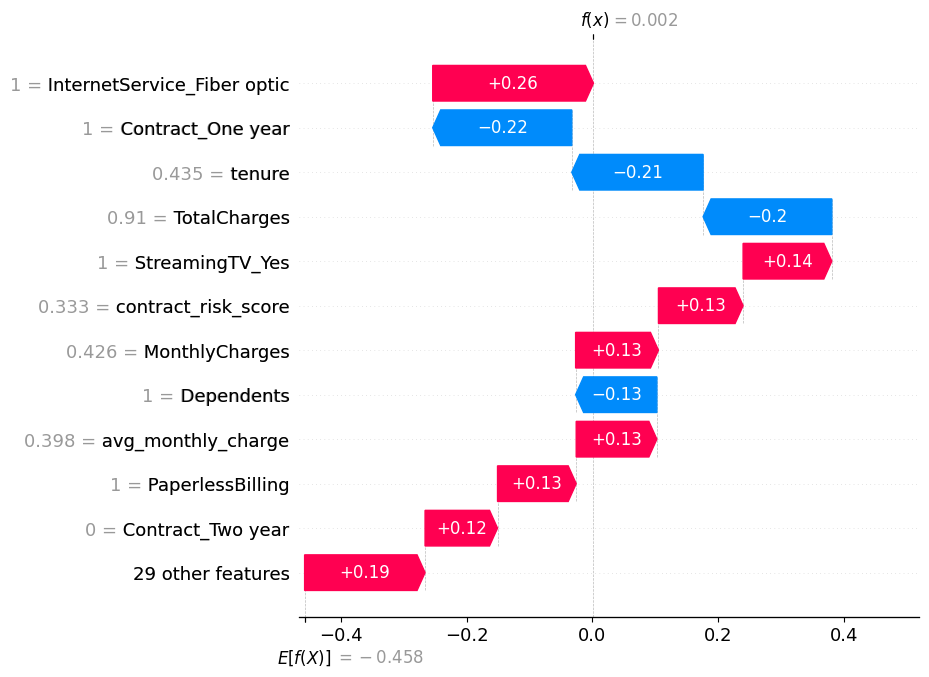

,case,index,pred_proba,shap_top_5,lime_top_5
0,high_risk_churn,889,0.9389,"[is_new_customer, charge_per_service, tenure, ...","[Contract_Two year <= 0.00, is_new_customer > ..."
1,low_risk_stay,162,0.0340,"[tenure, Contract_Two year, contract_risk_scor...","[Contract_Two year > 0.00, is_new_customer <= ..."
2,borderline,496,0.5005,"[InternetService_Fiber optic, Contract_One yea...","[Contract_Two year <= 0.00, is_new_customer <=..."


In [7]:
shap_single_values, x_for_single = compute_shap_values(best_model, x_test, max_samples=len(x_test))

comparison_rows = []
for label, idx in instance_ids.items():
    row_pos = np.where(x_for_single.index.to_numpy() == idx)[0][0]

    shap.plots.waterfall(shap_single_values[row_pos], max_display=12, show=True)

    shap_importance = np.abs(shap_single_values[row_pos].values)
    shap_top_idx = np.argsort(shap_importance)[::-1][:5]
    shap_top = [x_for_single.columns[i] for i in shap_top_idx]
    lime_top = [term for term, _ in lime_results[label]["explanation"][:5]]

    comparison_rows.append(
        {
            "case": label,
            "index": idx,
            "pred_proba": round(lime_results[label]["pred_proba"], 4),
            "shap_top_5": shap_top,
            "lime_top_5": lime_top,
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

## 5) Business Narrative from Explainability

In [8]:
narrative_points = []
if "Contract_Two year" in top_features or "Contract_One year" in top_features:
    narrative_points.append("Contract structure is a major churn driver; non-locked contracts carry higher risk.")
if "tenure" in top_features or "tenure_group_61+" in top_features:
    narrative_points.append("Tenure strongly influences churn; shorter-tenure customers are generally riskier.")
if "MonthlyCharges" in top_features or "charge_per_service" in top_features:
    narrative_points.append("Price pressure contributes to churn; higher recurring cost increases churn probability.")
if "TechSupport_Yes" in top_features or "OnlineSecurity_Yes" in top_features:
    narrative_points.append("Support/security service patterns are meaningful churn signals.")

print("Business narrative summary:")
for point in narrative_points:
    print("-", point)

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)
with open(models_dir / "explainability_summary.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "top_features": top_features,
            "dependence_features": dependence_features,
            "instance_ids": instance_ids,
            "lime_results": {
                k: {
                    "index": int(v["index"]),
                    "pred_proba": float(v["pred_proba"]),
                    "explanation": [(term, float(weight)) for term, weight in v["explanation"]],
                }
                for k, v in lime_results.items()
            },
            "narrative_points": narrative_points,
        },
        f,
        indent=2,
    )

print("Saved:", models_dir / "explainability_summary.json")

Business narrative summary:
- Contract structure is a major churn driver; non-locked contracts carry higher risk.
- Tenure strongly influences churn; shorter-tenure customers are generally riskier.
- Price pressure contributes to churn; higher recurring cost increases churn probability.
- Support/security service patterns are meaningful churn signals.
Saved: ../models/explainability_summary.json
